In [18]:
#@title Installs and Imports

# ==========================================
# 1. Setup & Installs
# ==========================================
!pip install playground mujoco_mjx brax mediapy
!pip install jaxued flax chex optax distrax wandb orbax-checkpoint pandas matplotlib

import os
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import functools
import orbax.checkpoint as ocp

os.environ['MUJOCO_GL'] = 'egl'
os.environ['XLA_FLAGS'] = '--xla_gpu_deterministic_ops=true'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

jax.tree_map = jax.tree_util.tree_map
if not hasattr(jax, 'tree_multimap'):
    jax.tree_multimap = jax.tree_util.tree_map

from flax import struct
import flax.linen as nn
from flax.linen.initializers import constant, orthogonal
from flax.training.train_state import TrainState as BaseTrainState
from flax.core import freeze
import distrax
import optax
import mediapy as media

import mujoco
from mujoco import mjx
from jaxued.linen import ResetRNN
from jaxued.environments import UnderspecifiedEnv
from mujoco_playground._src import mjx_env
from mujoco_playground._src.locomotion.go1 import joystick

mjx_env.ensure_menagerie_exists()




In [19]:
#@title Setup Drive Folder
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/all_policies_shared_local"
RESULTS_DIR = os.path.join(SAVE_DIR, "Evaluation_Results")
os.makedirs(RESULTS_DIR, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
#@title Reload base NN class
class Go1ActorCritic(nn.Module):
    """
    A continuous Actor-Critic MLP with an LSTM core, designed for the Go1.
    """
    action_dim: int

    @nn.compact
    def __call__(self, inputs, hidden):
        obs, dones = inputs

        # privileged state contains all observations: proprioceptive and exteroceptive
        x = obs['privileged_state']

        # 2. Base MLP embedding
        embedding = nn.Dense(256, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0), name="embed0")(x)
        embedding = nn.relu(embedding)

        # 3. Memory (LSTM)
        hidden, embedding = ResetRNN(nn.OptimizedLSTMCell(features=256))((embedding, dones), initial_carry=hidden)

        # 4. DECOUPLED ACTOR (Deeper)
        actor = nn.Dense(256, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0))(embedding)
        actor = nn.relu(actor)
        actor = nn.Dense(128, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0))(actor) # Extra layer!
        actor = nn.relu(actor)
        actor_mean = nn.Dense(self.action_dim, kernel_init=orthogonal(0.01), bias_init=constant(0.0))(actor)

        actor_log_std = self.param('log_std', constant(-0.5), (self.action_dim,))
        pi = distrax.MultivariateNormalDiag(loc=actor_mean, scale_diag=jnp.exp(actor_log_std))

        # 5. DECOUPLED CRITIC (Deeper)
        critic = nn.Dense(256, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0))(embedding)
        critic = nn.relu(critic)
        critic = nn.Dense(128, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0))(critic) # Extra layer!
        critic = nn.relu(critic)
        critic = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0))(critic)

        return hidden, pi, jnp.squeeze(critic, axis=-1)

    @staticmethod
    def initialize_carry(batch_dims):
        return nn.OptimizedLSTMCell(features=256).initialize_carry(jax.random.PRNGKey(0), (*batch_dims, 256))

In [21]:
#@title Track Generation (Flat Only for Suite II)

# ==========================================
# 2. Track Generation (Flat Only for Suite II)
# ==========================================
# Suite II ONLY tests on perfectly flat tracks to isolate dynamic robustness
ARENA_B_BLUEPRINTS = jnp.zeros((100, 8, 10))
DEMO_BLUEPRINT = jnp.zeros((8, 10))

@jax.jit
def generate_interleaved_segment(params, key):
    # Dummy segment generator for flat tracks
    return jnp.full((16, 128), 0.0)

@jax.jit
def blueprint_to_track(blueprint_8x10, key):
    keys_8 = jax.random.split(key, 8)
    terrain = jax.vmap(generate_interleaved_segment)(blueprint_8x10, keys_8).reshape(128, 128)
    track_width = 40
    center_y = 64
    terrain = terrain.at[:, :center_y - (track_width // 2)].set(-1.0)
    terrain = terrain.at[:, center_y + (track_width // 2):].set(-1.0)
    return terrain

In [22]:
from typing import Any, Tuple

#@title Environment & Policy Definitions

# ==========================================
# 3. Environment & Policy Definitions
# ==========================================
class DynamicJoystick(joystick.Joystick):
    """
    A lightweight subclass of the Go1 Joystick env that allows
    us to inject custom terrain models on the fly for jaxued.
    """

    def reset_with_model(self, rng, dynamic_mjx_model):
        # 1. Save the original static model
        original_model = self._mjx_model

        # 2. Temporarily replace it with our dynamic (and potentially batched) model
        self._mjx_model = dynamic_mjx_model

        # 3. Call the base class's standard reset method.
        # Under the hood, it will now use our dynamic model to compute physics!
        state = self.reset(rng)

        # 4. Restore the original model to keep the Python object clean
        self._mjx_model = original_model

        return state

    def step_with_model(self, dynamic_mjx_model, state, action):
        # Apply the exact same trick for the step function
        original_model = self._mjx_model
        self._mjx_model = dynamic_mjx_model

        next_state = self.step(state, action)

        self._mjx_model = original_model

        return next_state

@struct.dataclass
class Go1EnvParams:
    # The training/eval loop expects this specific name:
    max_steps_in_episode: int = 1500     # PARAMS

    # We'll keep this one too, just in case other parts of the base env use it:
    max_steps_per_episode: int = 1500    # PARAMS

    # Standard MuJoCo Playground parameters
    terminate_when_unhealthy: bool = True
    realign_to_center: bool = True

@struct.dataclass
class Go1State:
    base_state: Any  # This holds the MuJoCo/MJX physics data
    hfield_data: jax.Array  # This holds the 1D flattened terrain array
    last_action: jnp.ndarray

class Go1RoughUED(UnderspecifiedEnv):
    def __init__(self, base_env, nrow=256, ncol=256, z_min=-1.0, z_max=2.0):
        self.base_env = base_env
        self.nrow = nrow
        self.ncol = ncol
        self.action_size = self.base_env.action_size

        # CHANGED: Mute native command-tracking to allow custom directional injection
        # Mute rewards not needed for minimal shaping
        if hasattr(self.base_env.unwrapped, 'reward_scales'):
            scales = self.base_env.unwrapped.reward_scales

            # Mute overlaps
            if 'tracking_lin_vel' in scales: scales['tracking_lin_vel'] = 0.0
            if 'tracking_ang_vel' in scales: scales['tracking_ang_vel'] = 0.0
            if 'stand_still' in scales: scales['stand_still'] = 0.0
            if 'ang_vel_xy' in scales: scales['ang_vel_xy'] = 0.0
            if 'orientation' in scales: scales['orientation'] = 0.0
            if 'feet_clearance' in scales: scales['feet_clearance'] = 0.0
            if 'feet_height' in scales: scales['feet_height'] = 0.0

            # 1. Nerf Air Time: Lower it significantly so it stops farming air points
            if 'feet_air_time' in scales: scales['feet_air_time'] = 0.05
            # 2. Re-introduce a MILD bounce penalty. DeepMind's default is usually -2.0.
            # -0.1 is small enough that the robot is willing to jump over a hurdle,
            # but annoying enough that it won't bounce pointlessly on flat ground.

            if 'lin_vel_z' in scales: scales['lin_vel_z'] = -0.05
            if 'feet_slip' in scales: scales['feet_slip'] = 0.0
            if 'termination' in scales: scales['termination'] = 0.0
            if 'pose' in scales: scales['pose'] = 0.0
            if 'action_rate' in scales: scales['action_rate'] = -0.2

        # 1. Centralize the Z-span logic
        self.z_min = z_min
        self.z_max = z_max
        self.z_span = self.z_max - self.z_min

        # 2. Fix the MuJoCo model dimensions ONCE, right here
        mj_model = self.base_env.unwrapped.mj_model
        mj_model.hfield_size[0, 0] = 20.0  # Track length
        mj_model.hfield_size[0, 1] = 4.0   # Track width
        mj_model.hfield_size[0, 2] = self.z_span

        # Strip floor material and force bright grey (for better rendering)
        mj_model.geom_matid[0] = -1
        mj_model.geom_rgba[0] = [0.7, 0.7, 0.7, 1.0]

        # Push the correctly scaled model back to the MJX environment
        self.base_env.unwrapped._mjx_model = mjx.put_model(mj_model)

    @property
    def default_params(self) -> Go1EnvParams:
        return Go1EnvParams()

    def _generate_hfield(self, key, blueprint):
        # Baseline 1 Training: Perfectly flat terrain
        flat_terrain = jnp.zeros((self.nrow, self.ncol))
        normalized = (flat_terrain - self.z_min) / self.z_span
        return jnp.clip(normalized, 0.0, 1.0).T.flatten()

    def reset_to_level(self, key, level, params):
        rng_terrain, rng_reset = jax.random.split(key)

        flat_hfield = self._generate_hfield(rng_terrain, level)
        temp_model = self.base_env.unwrapped._mjx_model.replace(hfield_data=flat_hfield)
        base_state = self.base_env.reset_with_model(rng_reset, temp_model)

        # Custom Spawn Location: Drop from slightly above the terrain
        # The track spans from X = -20.0 to X = +20.0.
        # We spawn at -18.0 to give the robot a clean 2-meter flat runway before obstacles.
        new_qpos = base_state.data.qpos.at[0].set(-18.0)
        # CHANGED Center it on the Y axis
        new_qpos = new_qpos.at[1].set(0.0)
        # Slide the robot to find the true physical center of the track
        # Try 2.0, 3.0, -2.0, or -3.0 until it sits perfectly in the middle!
        # new_qpos = new_qpos.at[1].set(-0.2)
        # The Go1 is ~0.35m tall and the start line is flat (Z=0.0).
        # Spawning at 0.4m gives it a gentle, perfectly safe touchdown.
        max_obstacle_height = jnp.max(level)
        safe_z_height = max_obstacle_height + 0.4

        new_qpos = new_qpos.at[2].set(1.4)
        # new_qpos = new_qpos.at[2].set(0.4)

        # # ---> CHANGED: THE SPAWN ORIENTATION FIX <---
        # # MuJoCo quaternions are [w, x, y, z].
        # # [1, 0, 0, 0] is default. [0, 0, 0, 1] is a 180-degree rotation around the Z-axis.
        # new_qpos = new_qpos.at[3:7].set(jnp.array([0.0, 0.0, 0.0, 1.0]))

        # ==========================================================
        # ---> CHANGED THE ORIENTATION FIX <---
        # If [0, 0, 0, 1] didn't work, try [1.0, 0.0, 0.0, 0.0] here!
        new_qpos = new_qpos.at[3:7].set(jnp.array([1.0, 0.0, 0.0, 0.0]))
        # We step the environment with an empty action just to trigger the sensor update
        # dummy_action = jnp.zeros(self.action_size)
        # ==========================================================

        # Update the physics data with the new position
        new_data = base_state.data.replace(qpos=new_qpos)

        # Run one quick kinematics update so the simulator registers the new position
        new_data = mjx.kinematics(temp_model, new_data)
        base_state = base_state.replace(data=new_data)

        # Initialize last_action to zeros on reset
        initial_last_action = jnp.zeros(self.action_size)

        state = Go1State(base_state=base_state, hfield_data=flat_hfield, last_action=initial_last_action)
        return base_state.obs, state

    def step(self, key, state, action, params):
        temp_model = self.base_env.unwrapped._mjx_model.replace(hfield_data=state.hfield_data)
        next_base_state = self.base_env.step_with_model(temp_model, state.base_state, action)

        # --------------------------------------------------
        # EXTRACT DEEPMIND KINEMATIC SHAPING
        # --------------------------------------------------
        # (tracking_lin_vel is muted to 0.0 in __init__)
        dense_reward = next_base_state.reward

        # ---------------------------------------------------------
        # 1. Forward Velocity (Target Tracking: 4 km/hr)
        # ---------------------------------------------------------
        raw_v_x = next_base_state.data.qvel[0]

        # Max reward is +2.5 per step. No reward for walking backward.
        directional_bonus = 1.0 * jnp.clip(raw_v_x, 0.0, 2.5)

        # ---------------------------------------------------------
        # 2. Lateral Drift (The "Electric Fence")
        # ---------------------------------------------------------
        # Track is ~4m wide. Give a 2m wide safe zone (y = -1.0 to 1.0).
        # It can wander freely here. Outside 1.0, the penalty goes exponential.
        y_pos = next_base_state.data.qpos[1]

        # 1. Gentle pull towards the center (like before)
        gentle_center = jnp.square(y_pos)

        # 2. The Electric Fence: Kicks in ONLY if it drifts past 0.8 meters left or right.
        # The * 10.0 multiplier makes this a massive, terrifying wall to the neural network.
        edge_panic = jnp.square(jnp.maximum(0.0, jnp.abs(y_pos) - 0.8)) * 10.0

        centering_penalty = gentle_center + edge_panic

        # Punish sliding sideways like a crab
        v_y = next_base_state.data.qvel[1]
        strafe_penalty = jnp.square(v_y)

        # ---------------------------------------------------------
        # 3. Posture (Free the Pitch!)
        # ---------------------------------------------------------
        # Quaternions: [qw, qx, qy, qz] -> Indices: [3, 4, 5, 6]
        # qx (Index 4) = Roll (tilting side-to-side)
        # qz (Index 6) = Yaw (spinning like a top)
        # qy (Index 5) = Pitch. WE IGNORE THIS SO IT CAN REAR UP AND CLIMB!
        qx = next_base_state.data.qpos[4]
        qz = next_base_state.data.qpos[6]
        posture_penalty = jnp.square(qx) + jnp.square(qz)

        yaw_rate = next_base_state.data.qvel[5]
        yaw_penalty = jnp.square(yaw_rate)

        # ---------------------------------------------------------
        # 4. Action Smoothing (Loose enough to leap)
        # ---------------------------------------------------------
        # These are kept low enough that the robot is allowed to make
        # the sudden, explosive leg snaps required to jump over a hurdle.
        action_penalty = jnp.sum(jnp.square(action))
        action_rate_penalty = jnp.sum(jnp.square(action - state.last_action))

        # ---------------------------------------------------------
        # 5. The "Lazy Penalty" (The Stick)
        # ---------------------------------------------------------
        # If it stops moving (e.g., resting its nose against a wall), it bleeds points.
        # This actively forces it to jump to escape the penalty!
        lazy_penalty = jnp.where(raw_v_x < 0.2, -1.0, 0.0)

        # ---> ADD THIS: The Heading Penalty <---
        # qz (Index 6) is the Yaw quaternion. When facing perfectly forward, qz is 0.0.
        qz = next_base_state.data.qpos[6]
        heading_penalty = jnp.square(qz)

        # ---------------------------------------------------------
        # 6. Assemble Custom Reward
        # ---------------------------------------------------------
        custom_reward = (
            directional_bonus
            - (2.0 * centering_penalty)         # Massive weight for the Electric Fence!
            - (0.05 * strafe_penalty)
            - (1.0 * posture_penalty)        # Keeps spine upright but allows pitching
            - (0.05 * yaw_penalty)
            + lazy_penalty
        )

        # ---------------------------------------------------------
        # 7. Calculate Termination
        # ---------------------------------------------------------
        # Extract the local UP vector (Z-axis) from the quaternion to check if flipped
        x = next_base_state.data.qpos[4]
        y = next_base_state.data.qpos[5]
        up_z = 1.0 - 2.0 * (x**2 + y**2)
        is_flipped = up_z < 0.5

        # Check if it fell into a deep pit
        z_pos = next_base_state.data.qpos[2]
        fell_in_gap = z_pos < (self.z_min + 0.15)

        is_fallen = jnp.logical_or(is_flipped, fell_in_gap)

        # Check if it crossed the finish line
        x_pos = next_base_state.data.qpos[0]
        reached_goal = x_pos > 16.0

        done = jnp.logical_or(next_base_state.done, is_fallen)
        done = jnp.logical_or(done, reached_goal)

        # ---------------------------------------------------------
        # 8. Apply Final Reward (No Alive Bonus!)
        # ---------------------------------------------------------
        # If it falls, it gets a flat -10.0 (death is painful).
        # If it reaches the goal, it gets a +10.0 bonus!
        final_reward = jnp.where(is_fallen, -10.0, custom_reward + dense_reward)
        final_reward = jnp.where(reached_goal, custom_reward + dense_reward + 10.0, final_reward)

        # Update state, remembering the action for the next step's rate penalty
        next_state = Go1State(base_state=next_base_state, hfield_data=state.hfield_data, last_action=action)
        return next_base_state.obs, next_state, final_reward, done, next_base_state.info

# --- Perturbation Wrappers ---
class Go1Eval_Control(Go1RoughUED):
    pass

class Go1Eval_Ice(Go1RoughUED):
    def __init__(self, base_env, nrow=256, ncol=256, **kwargs):
        super().__init__(base_env, nrow=nrow, ncol=ncol, **kwargs)
        # geom_friction[0, 0] targets the sliding friction of the floor
        new_friction = self.base_env.unwrapped._mjx_model.geom_friction.at[0, 0].set(0.1)
        self.base_env.unwrapped._mjx_model = self.base_env.unwrapped._mjx_model.replace(geom_friction=new_friction)

class Go1Eval_Heavy(Go1RoughUED):
    def __init__(self, base_env, nrow=256, ncol=256, **kwargs):
        super().__init__(base_env, nrow=nrow, ncol=ncol, **kwargs)
        # body_mass[1] targets the trunk/torso of the Go1
        new_mass = self.base_env.unwrapped._mjx_model.body_mass.at[1].set(
            self.base_env.unwrapped._mjx_model.body_mass[1] + 10.0
        )
        self.base_env.unwrapped._mjx_model = self.base_env.unwrapped._mjx_model.replace(body_mass=new_mass)

class Go1Eval_Noisy(Go1RoughUED):
    def step(self, key, state, action, params):
        # Injects 15% Gaussian noise into the motor commands before physics calculation
        noise = jax.random.normal(key, action.shape) * 0.25
        noisy_action = jnp.clip(action + noise, -1.0, 1.0)

        # Because we use super().step, it returns the exact 5-tuple required (including the new Go1State dataclass)
        return super().step(key, state, noisy_action, params)

In [23]:
#@title Evaluation and Plotting Engines

# ==========================================
# 4. Evaluation Engine
# ==========================================
def evaluate_rnn(rng, env, env_params, train_state, init_hstate, init_obs, init_env_state, max_episode_length):
    num_levels = jax.tree_util.tree_leaves(init_obs)[0].shape[0]
    def step(carry, _):
        rng, hstate, obs, state, done, mask = carry
        hstate, pi, _ = train_state.apply_fn(train_state.params, jax.tree_util.tree_map(lambda x: x[None, ...], (obs, done)), hstate)
        action = pi.mean().squeeze(0) # Deterministic evaluation
        obs, next_state, _, done, _ = jax.vmap(env.step, in_axes=(0, 0, 0, None))(jax.random.split(rng, num_levels), state, action, env_params)
        done = done.astype(bool)
        return (rng, hstate, obs, next_state, done, mask & ~done), state

    _, states = jax.lax.scan(step, (rng, init_hstate, init_obs, init_env_state, jnp.zeros(num_levels, dtype=bool), jnp.ones(num_levels, dtype=bool)), None, length=max_episode_length)
    return states

def load_policy(ckpt_dir, env, env_params):
    print(f"Loading checkpoint from: {ckpt_dir}...")
    dummy_obs, _ = env.reset_to_level(jax.random.PRNGKey(0), jnp.zeros((8, 10)), env_params)
    dummy_obs = jax.tree_util.tree_map(lambda x: jnp.repeat(jnp.repeat(x[None, ...], 1, axis=0)[None, ...], 128, axis=0), dummy_obs)
    network = Go1ActorCritic(env.action_size)
    network_params = network.init(jax.random.PRNGKey(0), (dummy_obs, jnp.zeros((128, 1))), Go1ActorCritic.initialize_carry((1,)))
    dummy_state = BaseTrainState.create(apply_fn=network.apply, params=network_params, tx=optax.adam(1e-4))

    raw_checkpoint = ocp.StandardCheckpointer().restore(os.path.abspath(ckpt_dir))
    return dummy_state.replace(params=freeze(raw_checkpoint['params']))

@functools.partial(jax.jit, static_argnames=("eval_env", "max_steps"))
def run_arena_eval(rng, train_state, eval_env, env_params, blueprints, max_steps):
    num_levels = blueprints.shape[0]
    init_obs, init_env_state = jax.vmap(eval_env.reset_to_level, (0, 0, None))(jax.random.split(rng, num_levels), blueprints, env_params)
    states = evaluate_rnn(rng, eval_env, env_params, train_state, Go1ActorCritic.initialize_carry((num_levels,)), init_obs, init_env_state, max_steps)

    x_positions = states.base_state.data.qpos[..., 0]
    max_x_positions = jnp.nanmax(x_positions, axis=0)

    completion_fractions = jnp.clip((max_x_positions - (-18.0)) / (19.0 - (-18.0)), 0.0, 1.0)
    solve_rates = jnp.where(max_x_positions > 19.0, 1.0, 0.0)
    return jnp.nan_to_num(solve_rates.mean(), nan=0.0), jnp.nan_to_num(completion_fractions.mean(), nan=0.0)

# ==========================================
# 5. Plotting Engine
# ==========================================
def save_and_plot_robustness(results_data, save_dir):
    df_results = pd.DataFrame(results_data).set_index("Policy")
    csv_path = os.path.join(save_dir, "Suite_2_Dynamic_Robustness.csv")
    df_results.to_csv(csv_path)
    print(f"\nResults saved to: {csv_path}")

    # Plot Setup: Group by Condition, compare Policies
    conditions = ["Control", "Ice", "Heavy", "Noisy"]
    policies = df_results.index.tolist()

    x = np.arange(len(conditions))
    width = 0.8 / len(policies)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    fig, ax = plt.subplots(figsize=(12, 6))

    for i, policy in enumerate(policies):
        # Extract the distance metrics for this policy across the 4 conditions
        policy_scores = [float(df_results.loc[policy, f"{cond} (Dist %)"].strip('%')) for cond in conditions]
        offset = (i - len(policies)/2) * width + width/2
        ax.bar(x + offset, policy_scores, width, label=policy, color=colors[i % len(colors)])

    ax.set_ylabel('Distance Solved (%)', fontweight='bold')
    ax.set_title('Suite II: Dynamic Robustness (Planar Overfitting Analysis)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(conditions, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.legend(loc='lower left', bbox_to_anchor=(1, 0.5))
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plot_path = os.path.join(save_dir, "Suite_2_Bar_Chart.png")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150)
    plt.show()

In [24]:
#@title Execution Routine

# ==========================================
# 6. Execution Routine
# ==========================================
def run_robustness_suite(policy_paths):
    rng_eval = jax.random.PRNGKey(999)
    env_params = Go1EnvParams()

    arenas = {
        "Control": Go1Eval_Control,
        "Ice": Go1Eval_Ice,
        "Heavy": Go1Eval_Heavy,
        "Noisy": Go1Eval_Noisy
    }

    results_data = []

    for policy_name, path in policy_paths.items():
        rng_eval, rng_load = jax.random.split(rng_eval)
        # We use the base control env to load the network structure
        temp_env = Go1Eval_Control(DynamicJoystick(task="rough_terrain"), nrow=256, ncol=256)
        train_state = load_policy(path, temp_env, env_params)

        policy_results = {"Policy": policy_name}

        for arena_name, EnvClass in arenas.items():
            print(f"Evaluating {policy_name} on {arena_name}...")
            test_env = EnvClass(DynamicJoystick(task="rough_terrain"), nrow=256, ncol=256)

            solve_rate, distance = run_arena_eval(
                rng_eval, train_state, test_env, env_params, ARENA_B_BLUEPRINTS, env_params.max_steps_in_episode
            )

            policy_results[f"{arena_name} (Solve %)"] = f"{float(solve_rate)*100:.1f}%"
            policy_results[f"{arena_name} (Dist %)"] = f"{float(distance)*100:.1f}%"

        results_data.append(policy_results)
        print("-" * 50)
    if results_data:
        save_and_plot_robustness(results_data, RESULTS_DIR)


Loading checkpoint from: /content/drive/MyDrive/all_policies_shared_local/Baseline1_NoObstacles_MinimalRewards_Apr9_final_policy_ckpt...
Evaluating Baseline 1 (Min) on Control...
Evaluating Baseline 1 (Min) on Ice...
Evaluating Baseline 1 (Min) on Heavy...
Evaluating Baseline 1 (Min) on Noisy...
--------------------------------------------------
Loading checkpoint from: /content/drive/MyDrive/all_policies_shared_local/Baseline2_NoObstacles_FullShaping_final_policy_ckpt...
Evaluating Baseline 2 (Dense) on Control...
Evaluating Baseline 2 (Dense) on Ice...
Evaluating Baseline 2 (Dense) on Heavy...
Evaluating Baseline 2 (Dense) on Noisy...
--------------------------------------------------
Loading checkpoint from: /content/drive/MyDrive/all_policies_shared_local/Baseline3_DR_final_policy_ckpt...
Evaluating DR on Control...
Evaluating DR on Ice...
Evaluating DR on Heavy...
Evaluating DR on Noisy...
--------------------------------------------------
Loading checkpoint from: /content/drive/M

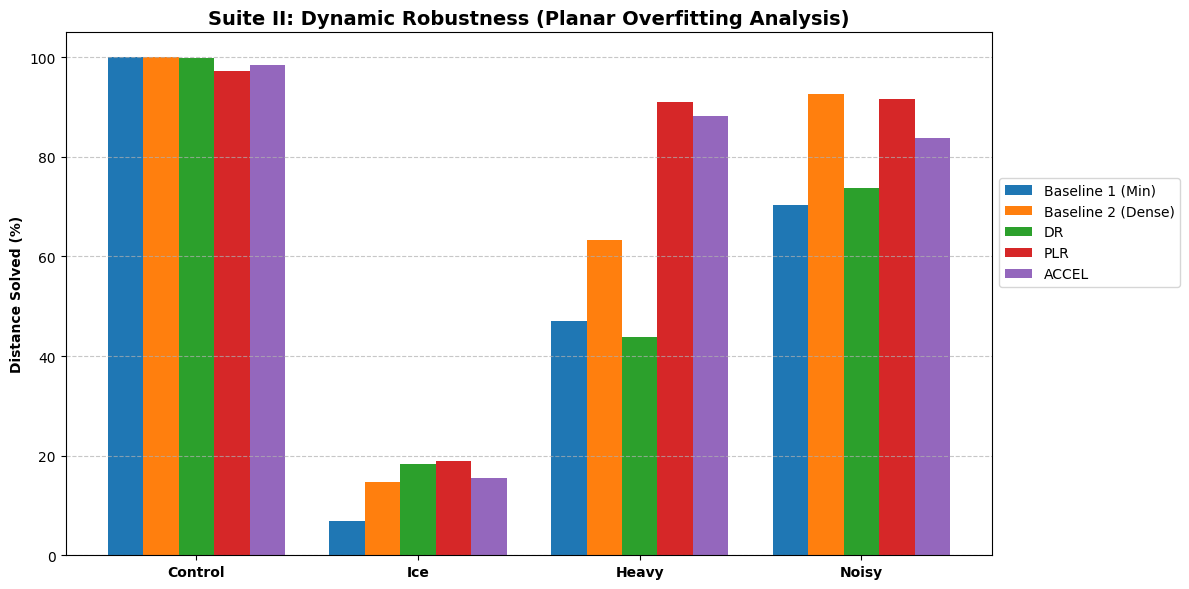

In [25]:
#@title RUN ROBUSTNESS EVALS
policies_to_test = {
    "Baseline 1 (Min)": f"{SAVE_DIR}/Baseline1_NoObstacles_MinimalRewards_Apr9_final_policy_ckpt",
    "Baseline 2 (Dense)": f"{SAVE_DIR}/Baseline2_NoObstacles_FullShaping_final_policy_ckpt",
    "DR": f"{SAVE_DIR}/Baseline3_DR_final_policy_ckpt",
    "PLR": f"{SAVE_DIR}/PLR_final_policy_ckpt",
    "ACCEL": f"{SAVE_DIR}/ACCEL_8apr_final_policy_ckpt"
}
run_robustness_suite(policies_to_test)